In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
from pass_at_k import pass_at_k_rates_with_sample_variance, pass_at_k_rates
import math
from pass_at_k import (
    BetaBinomialPassAtK,
    bootstrap_pass_at_k_ci,
    NPMLEBinomialPassAtK,
    MixtureBinomialPassAtK,
    DirichletProcessBetaPassAtK,
    TailStitchedNPMLEPassAtK,
    SplicedPosteriorPassAtK,
    KSplicedPassAtK,
    BetaSmoothedNPMLEPassAtK,
    BetaMixtureNPMLEPassAtK,
    CrossFittedBetaBinomialPassAtK,
)
import numpy as np


def compute(data, k_values, budget_per_problem, random_state=42):
    """Split trials per problem: first `budget` for estimators, rest for MVUE."""
    rng = np.random.RandomState(random_state)
    n_problems, n_samples = data.shape
    b = min(int(budget_per_problem), n_samples // 2)
    if b <= 0:
        raise ValueError(
            f"budget_per_problem must be in [1, {n_samples // 2}]; got {budget_per_problem}"
        )

    data_est = []
    data_gt = []
    for i in range(n_problems):
        gens = data[i]
        perm = rng.permutation(n_samples)
        gens = gens[perm]
        data_est.append(gens[:b])
        data_gt.append(gens[b:])
    data_est = np.asarray(data_est)
    data_gt = np.asarray(data_gt)

    k_values = np.asarray(k_values, dtype=int)
    max_k = data_gt.shape[1]
    k_values = np.unique(k_values[(k_values >= 1) & (k_values <= max_k)])
    if k_values.size == 0:
        raise ValueError(f"No k values in [1, {max_k}]")

    gt, gt_var = pass_at_k_rates_with_sample_variance(
        data_gt, k_values
    )

    mvue = pass_at_k_rates(data_est, k_values)

    data = {
        "successes": np.array([gens.sum(dtype=int) for gens in data_est]),
        "attempts": np.full(n_problems, b, dtype=int),
    }

    est = BetaBinomialPassAtK(verbose=False)

    est.fit(data['successes'], data['attempts'])
    est_int = est.predict(k_values, method="integrated", bias_correct=False)
    est_posterior = est.predict(k_values, method="posterior")

    est_mixture = MixtureBinomialPassAtK(verbose=False, reg_alpha=0.001)
    est_mixture.fit(data['successes'], data['attempts'])
    est_mixture_pass = est_mixture.predict(k_values)

    est_dp = DirichletProcessBetaPassAtK()
    est_dp.fit(data['successes'], data['attempts'])
    est_dp_pass = est_dp.predict(k_values)

    est_tail = TailStitchedNPMLEPassAtK()
    est_tail.fit(data['successes'], data['attempts'])
    est_tail_pass = est_tail.predict(k_values)

    # est_npmle = NPMLEBinomialPassAtK(verbose=False)
    # est_npmle.fit(data['successes'], data['attempts'])
    # est_npmle_pass = est_npmle.predict(k_values)

    # est_npmle_plugin = est_npmle.predict(k_values, method="plugin", bias_correct=False)
    # est_npmle_plugin_bc = est_npmle.predict(k_values, method="plugin", bias_correct=True)

    est_beta_mixture_npmle = BetaMixtureNPMLEPassAtK(verbose=True)
    est_beta_mixture_npmle.tune_nu(data['successes'], data['attempts'])
    est_beta_mixture_npmle.fit(data['successes'], data['attempts'])
    est_beta_mixture_npmle = est_beta_mixture_npmle.predict(k_values, method='posterior')

    est_npmle_reg = NPMLEBinomialPassAtK(verbose=False, reg_alpha=0.001)
    est_npmle_reg.fit(data['successes'], data['attempts'])
    est_npmle_reg_pass = est_npmle_reg.predict(k_values)

    # est_npmle_reg_plugin = est_npmle_reg.predict(k_values, method="plugin", bias_correct=False)
    # est_npmle_reg_plugin_bc = est_npmle_reg.predict(k_values, method="plugin", bias_correct=True)

    # boot_int, lower_int, upper_int = bootstrap_pass_at_k_ci(
    #     lambda: BetaBinomialPassAtK(verbose=False),
    #     data['successes'], data['attempts'],
    #     k_values, n_bootstraps=200,
    #     predict_configs=[{"method": "integrated"}]
    # )

    # est_spliced = SplicedPosteriorPassAtK(
    #     BetaBinomialPassAtK(verbose=False),
    #     NPMLEBinomialPassAtK(verbose=False, reg_alpha=0.001)
    # )
    # est_spliced.fit(data['successes'], data['attempts'])
    # est_spliced_pass = est_spliced.predict(k_values)

    est_kspliced = KSplicedPassAtK(
        BetaBinomialPassAtK(verbose=False),
        NPMLEBinomialPassAtK(verbose=False, reg_alpha=0.001),
    )
    est_kspliced.fit(data['successes'], data['attempts'])
    est_kspliced_pass = est_kspliced.predict(k_values)

    # est_kspliced_beta = KSplicedPassAtK(
    #     BetaBinomialPassAtK(verbose=False),
    #     NPMLEBinomialPassAtK(verbose=False, reg_alpha=0.001),
    #     extrapolation="beta_posterior"
    # )
    # est_kspliced_beta.fit(data['successes'], data['attempts'])
    # est_kspliced_beta_pass = est_kspliced_beta.predict(k_values)

    est_beta_smoothed = BetaSmoothedNPMLEPassAtK(verbose=False)
    est_beta_smoothed.fit(data['successes'], data['attempts'])
    est_beta_smoothed_pass = est_beta_smoothed.predict(k_values)

    est_beta_xfit = CrossFittedBetaBinomialPassAtK(verbose=False)
    est_beta_xfit.fit(data['successes'], data['attempts'])
    est_beta_xfit_pass = est_beta_xfit.predict(k_values)


    fit = {
        "k_values": k_values,
        "estimate": est_int,
        # "estimate_boot": boot_int,
        "estimate_posterior": est_posterior,
        "mvue": mvue,
        "gt": gt,
        "gt_var": gt_var,
        "mixture_binomial": est_mixture_pass,
        "dp": est_dp_pass,
        "tail": est_tail_pass,
        # "lower_ci": lower_int,
        # "upper_ci": upper_int,
        # "npmle": est_npmle_pass,
        # "beta_mixture_integrated": est_beta_mixture_npmle_integrated,
        "beta_mixture": est_beta_mixture_npmle,
        # # "efron_g": est_efron_g_pass,
        # "npmle_plugin": est_npmle_plugin,
        # "npmle_plugin_bc": est_npmle_plugin_bc,
        "npmle_reg": est_npmle_reg_pass,
        # "npmle_reg_plugin": est_npmle_reg_plugin,
        # "npmle_reg_plugin_bc": est_npmle_reg_plugin_bc,
        # "spliced": est_spliced_pass,
        "kspliced": est_kspliced_pass,
        "beta_smoothed": est_beta_smoothed_pass,
        "beta_xfit": est_beta_xfit_pass,
    }

    return fit


In [5]:
import math
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

import pickle
with open('r1_reasoning.pkl', 'rb') as f:
    data_dict = pickle.load(f)

# Reasoning sets: 128 samples/prompt (monkey_business in compare_real_v2 uses 10000)
SAMPLES_PER_PROMPT = 128
budget_per_problem = 10
MVUE_SAMPLES = SAMPLES_PER_PROMPT - budget_per_problem

# Integer k, step 1: k = 1, ..., MVUE_SAMPLES (max = holdout fold width)
# (Compute uses all k values; plots show x-axis ticks only at powers of 2.)
k_values = np.arange(1, MVUE_SAMPLES + 1)
# k_values = np.arange(1, 10)

cfg_to_data = data_dict

cfg_names = list(cfg_to_data.keys())
n_cfg = len(cfg_names)

# Precompute results per config
results = {}
for cfg in cfg_names:
    oracle_data = cfg_to_data[cfg]["data"]
    if oracle_data.shape[1] != SAMPLES_PER_PROMPT:
        raise ValueError(
            f"{cfg}: expected {SAMPLES_PER_PROMPT} samples, got {oracle_data.shape[1]}"
        )
    fit = compute(oracle_data, k_values, budget_per_problem)

    successes_oracle = np.sum(oracle_data, axis=1)
    attempts_oracle = np.full(oracle_data.shape[0], oracle_data.shape[1], dtype=np.int64)
    est_oracle = BetaBinomialPassAtK(verbose=False).fit(successes_oracle, attempts_oracle)
    alpha_oracle, beta_oracle = est_oracle.alpha_, est_oracle.beta_

    p_hat = successes_oracle / attempts_oracle.astype(float)
    p_hat_pos = p_hat[p_hat > 0]

    results[cfg] = {
        "fit": fit,
        "alpha": alpha_oracle,
        "beta": beta_oracle,
        "p_hat": p_hat,
        "p_hat_pos": p_hat_pos,
        "n_samples": oracle_data.shape[1],
    }


/home/dkp45/inference-scaling-law/pass_at_k.py:1299: RuntimeWarning: divide by zero encountered in scalar divide
  beta_tail = (1.0 - t_0) / t_0
/home/dkp45/inference-scaling-law/pass_at_k.py:1303: RuntimeWarning: invalid value encountered in divide
  tail_decay = beta_tail / (k_values + beta_tail) # shape: (len_k,)


Starting CV tuning for nu across candidates: [0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]
  nu =   0.1 | Mean Val NLL: 3.8835
  nu =   0.2 | Mean Val NLL: 3.7400
  nu =   0.5 | Mean Val NLL: 3.6884
  nu =   1.0 | Mean Val NLL: 3.6976
  nu =   2.0 | Mean Val NLL: 3.7146
  nu =   4.0 | Mean Val NLL: 3.7261
  nu =   8.0 | Mean Val NLL: 3.7262
  nu =  16.0 | Mean Val NLL: 3.7263
  nu =  32.0 | Mean Val NLL: 3.7313
Optimal nu found: 0.5
Beta-Mixture NPMLE converged at iteration 969
Beta-Mixture NPMLE converged at iteration 969
Starting CV tuning for nu across candidates: [0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]
  nu =   0.1 | Mean Val NLL: 3.1185
  nu =   0.2 | Mean Val NLL: 2.9782
  nu =   0.5 | Mean Val NLL: 2.9234
  nu =   1.0 | Mean Val NLL: 2.8860
  nu =   2.0 | Mean Val NLL: 2.8341
  nu =   4.0 | Mean Val NLL: 2.8119
  nu =   8.0 | Mean Val NLL: 2.8195
  nu =  16.0 | Mean Val NLL: 2.8233
  nu =  32.0 | Mean Val NLL: 2.8282
Optimal nu found: 4.0
Beta-Mixture NPMLE conve

### Notes (128-sample reasoning data)

Compared to `compare_real_v2.ipynb` (10k trials/problem): `budget_per_problem` trials fit estimators; the rest evaluate MVUE. Pass@k uses **every integer** `k` from `1` to `k=MVUE_SAMPLES` (step 1); figures only label **powers of 2** on the k-axis. Prior panels use bins aligned to discrete rates `k/128` and a separate y-axis for the Beta PDF.

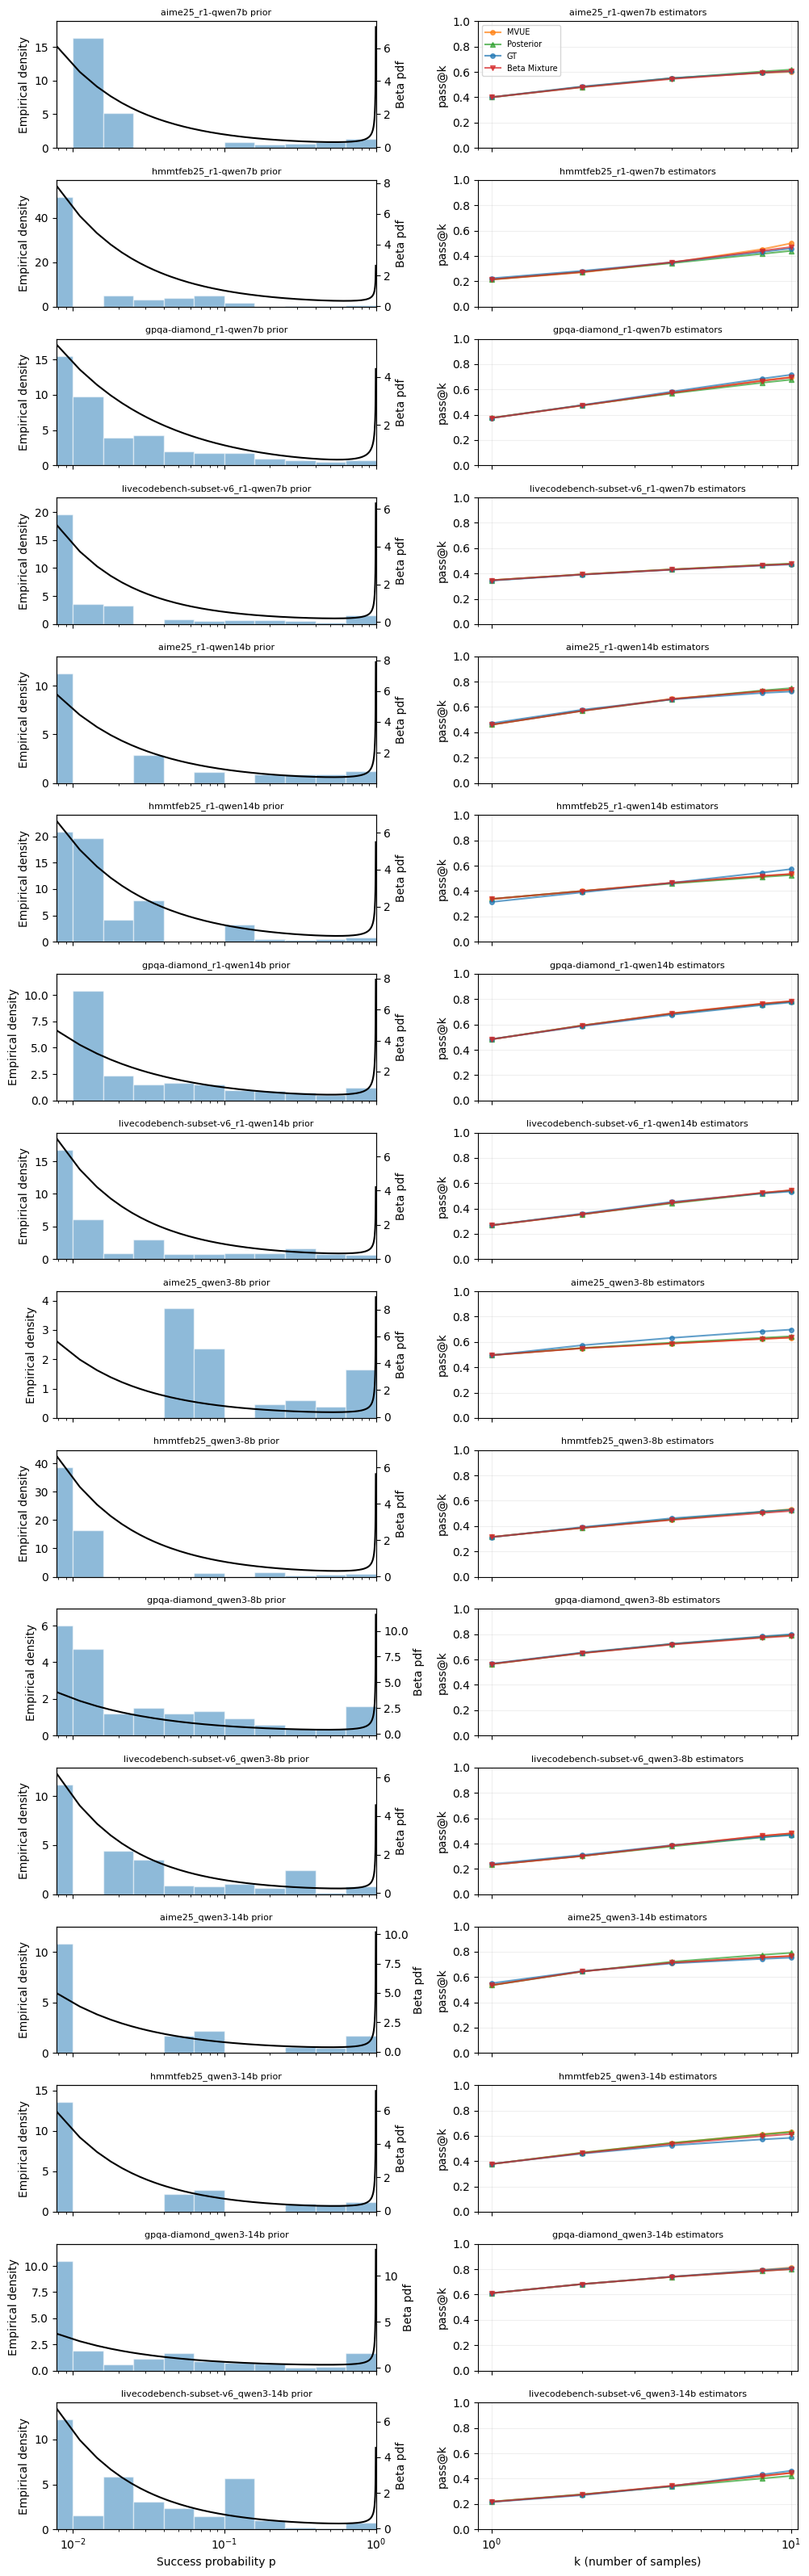

In [10]:
# One big figure with n_cfg rows and 2 columns (20 axes if n_cfg=10)
fig, axes = plt.subplots(n_cfg, 2, figsize=(10, max(6, 2.0 * n_cfg)), sharex="col")

# If only one config, make axes 2D-compatible
if n_cfg == 1:
    axes = np.array([axes])

def _xticks_powers_of_two(k_lo, k_hi):
    """X-axis ticks at powers of 2 in [k_lo, k_hi] for decluttered pass@k plots."""
    k_lo = int(np.ceil(float(k_lo)))
    k_hi = int(np.floor(float(k_hi)))
    ticks = []
    p = 1
    while p <= k_hi:
        if p >= k_lo:
            ticks.append(p)
        p <<= 1
    return ticks


def _mask_k_powers_of_two(k):
    """True at powers of 2 in k, plus always min(k) and max(k)."""
    k = np.asarray(k, dtype=int)
    if k.size == 0:
        return k.astype(bool)
    pow2 = (k >= 1) & ((k & (k - 1)) == 0)
    endpoints = (k == k.min()) | (k == k.max())
    return pow2 | endpoints


# If True, estimator curves only draw (k, y) at powers of two (still computed on all k above).
PASSK_PLOT_POW2_K_ONLY = True
K_PLOT_MAX = 10

p_edges = np.arange(0, SAMPLES_PER_PROMPT + 1) / SAMPLES_PER_PROMPT
p_plot = np.linspace(1 / SAMPLES_PER_PROMPT, 1.0, 300)

for row, cfg in enumerate(cfg_names):
    res = results[cfg]
    fit = res["fit"]
    k_plot = np.asarray(fit["k_values"])
    plot_mask = (k_plot >= 1) & (k_plot <= K_PLOT_MAX)
    k_plot = k_plot[plot_mask]

    p_hat_pos = res["p_hat_pos"]

    ax_prior = axes[row, 0]
    ax_est = axes[row, 1]

    # Left: empirical p_hat (discrete k/128) + Beta prior on separate y scale
    ax_prior.hist(
        p_hat_pos,
        # bins=p_edges,
        bins=np.logspace(-4, 0, 21),
        density=True,
        alpha=0.5,
        color="C0",
        edgecolor="white",
    )
    ax_pdf = ax_prior.twinx()
    ax_pdf.plot(
        p_plot,
        beta_dist.pdf(p_plot, res["alpha"], res["beta"]),
        "k-",
        linewidth=1.5,
    )
    ax_prior.set_xscale("log")
    ax_prior.set_xlim(1 / SAMPLES_PER_PROMPT, 1)
    ymax = ax_prior.get_ylim()[1]
    ax_prior.set_ylim(0, ymax * 1.1)
    if row == n_cfg - 1:
        ax_prior.set_xlabel("Success probability p")
    ax_prior.set_ylabel("Empirical density")
    ax_pdf.set_ylabel("Beta pdf")
    ax_prior.set_title(f"{cfg} prior", fontsize=8)

    # Right: estimators vs MVUE
    # ax_est.fill_between(
    #     k_plot,
    #     fit["lower_ci"],
    #     fit["upper_ci"],
    #     alpha=0.2,
    #     color="C1",
    # )
    estimator_specs = [
        # ("estimate", "Integrated", "s-", "C1"),
        ("mvue", "MVUE", "o-", "C1"),
        ("estimate_posterior", "Posterior", "^-", "C2"),
        ("gt", "GT", "o-", "C0"),
        ("beta_mixture", "Beta Mixture", "v-", "C3"),
        # ("mixture_binomial", "Mixture", "v-", "C3"),
        # ("dp", "DP", "^-", "C4"),
        # ("tail", "Tail", "o-", "C5"),
        # ("spliced", "Spliced", "^-", "C6"),
        # ("kspliced", "KSpliced", "o-", "C7"),
        # ("kspliced_beta", "KSpliced Beta", "^-", "C9"),
        # ("npmle", "NPMLE", "^-", "C2"),
        # ("npmle_mixture", "NPMLE Mixture", "v-", "C3"),
        # # ("efron_g", "Efron G", "^-", "C4"),
        # ("npmle_plugin", "NPMLE Plugin", "o-", "C5"),
        # ("npmle_plugin_bc", "NPMLE Plugin (bias-corrected)", "v-", "C6"),
        # ("npmle_reg", "NPMLE Reg", "^-", "C8"),
        # ("npmle_reg_plugin", "NPMLE Reg Plugin", "o-", "C8"),
        # ("npmle_reg_plugin_bc", "NPMLE Reg Plugin (bias-corrected)", "v-", "C9"),
        # ("beta_smoothed", "Beta Smoothed", "^-", "C9"),
        # ("beta_xfit", "Beta Xfit", "^-", "C10"),
    ]

    for key, label, style, color in estimator_specs:
        if key in fit:
            y_series = np.asarray(fit[key], dtype=float)[plot_mask]
            if PASSK_PLOT_POW2_K_ONLY:
                m_k = _mask_k_powers_of_two(k_plot)
                ax_est.plot(
                    k_plot[m_k],
                    y_series[m_k],
                    style,
                    color=color,
                    linewidth=1.5,
                    markersize=4,
                    label=label,
                    alpha=0.7,
                )
            else:
                ax_est.plot(
                    k_plot,
                    y_series,
                    style,
                    color=color,
                    linewidth=1.5,
                    markersize=4,
                    label=label,
                    alpha=0.5,
                )
    
    ax_est.set_xlim(k_plot.min() * 0.9, K_PLOT_MAX * 1.05)
    ax_est.set_xticks(_xticks_powers_of_two(k_plot.min(), k_plot.max()))
    ax_est.set_ylim(0.0, 1.0)
    # ax_est.set_yscale("log")
    ax_est.set_xscale("log")
    if row == n_cfg - 1:
        ax_est.set_xlabel("k (number of samples)")
    ax_est.set_ylabel("pass@k")
    ax_est.grid(True, alpha=0.2)
    ax_est.set_title(f"{cfg} estimators", fontsize=8)

# Only put legend on the first estimator axis to keep things readable
first_est_ax = axes[0, 1]
handles, labels = first_est_ax.get_legend_handles_labels()
first_est_ax.legend(handles, labels, fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("reasoning_estimators.png", dpi=300)
plt.show()



In [ ]:
import numpy as np
import pandas as pd

K_MAX = 10

cfg_to_data = data_dict

# estimator_name -> {cfg -> WRMSE}
estimator_errors = {}

for cfg, oracle_data in cfg_to_data.items():
    oracle_data = oracle_data['data']
    # 1) Estimator curves on sampled data
    # fit = compute(oracle_data, k_values, total_budget, sampler="uniform")
    fit = results[cfg]['fit']
    k_plot = np.asarray(fit["k_values"])
    k_mask = (k_plot >= 1) & (k_plot <= K_MAX)
    gt_curve = np.asarray(fit["gt"], dtype=float)[k_mask]
    variance_curve = np.asarray(fit["gt_var"], dtype=float)[k_mask]
    # # 2) Inverse-variance weighting curve from oracle p_true
    # successes_oracle = np.sum(oracle_data, axis=1)
    # attempts_oracle = np.full(oracle_data.shape[0], oracle_data.shape[1], dtype=np.int64)
    # p_true = successes_oracle / attempts_oracle.astype(float)

    # n_tasks = len(p_true)
    # m_samples_per_task = total_budget / n_tasks

    # k_vec = k_values[:, None]
    # p_vec = p_true[None, :]
    # variance_curve = (k_vec**2 / (n_tasks**2 * m_samples_per_task)) * np.sum(
    #     p_vec * (1.0 - p_vec) ** (2 * k_vec - 1),
    #     axis=1,
    # )
    # variance_curve = variance_curve + 1e-12

    # 3) WRMSE for each estimator in fit (except MVUE itself)
    for est_name, est_curve in fit.items():
        if est_name in ["gt", "lower_ci", "upper_ci", "estimate_boot", "k_values", "gt_var"]:
            continue
        est_curve = np.asarray(est_curve, dtype=float)[k_mask]
        # wmse = np.mean(((est_curve - mvue_curve) ** 2) / variance_curve)
        wmse = np.mean(((est_curve - gt_curve) ** 2))
        wrmse = float(np.sqrt(wmse))
        estimator_errors.setdefault(est_name, {})[cfg] = wrmse

# ---------- Reporting (clean aligned table) ----------
error_df = pd.DataFrame(estimator_errors).sort_index()
error_df.index.name = "config"

# Pretty column names
error_df = error_df.rename(columns={c: f"WRMSE[{c}]" for c in error_df.columns})

# Per-config table
display(error_df.style.format("{:.4f}"))

# Summary table (mean/std across configs)
summary_df = pd.DataFrame({
    "mean": error_df.mean(axis=0),
    "std": error_df.std(axis=0),
    "min": error_df.min(axis=0),
    "max": error_df.max(axis=0),
}).sort_values("mean")

display(summary_df.style.format("{:.4f}"))

# If you need plain text output too:
print("\nPer-config WRMSE table:\n")
print(error_df.to_string(float_format=lambda x: f"{x:.4f}"))

print("\nEstimator summary (sorted by mean WRMSE):\n")
print(summary_df.to_string(float_format=lambda x: f"{x:.4f}"))

,WRMSE[estimate],WRMSE[estimate_posterior],WRMSE[mvue],WRMSE[mixture_binomial],WRMSE[dp],WRMSE[tail],WRMSE[beta_mixture],WRMSE[npmle_reg],WRMSE[kspliced],WRMSE[beta_smoothed],WRMSE[beta_xfit]
config,,,,,,,,,,,
aime25_qwen3-14b,0.0752,0.0656,0.0470,0.0702,0.1332,nan,0.0064,0.0627,0.0505,0.0037,0.0744
aime25_qwen3-8b,0.0360,0.0385,0.1223,0.0793,0.1751,nan,0.0599,0.0709,0.0452,0.0874,0.0334
aime25_r1-qwen14b,0.0672,0.0675,0.0456,0.0071,0.1607,nan,0.0106,0.0067,0.0598,0.0093,0.0753
aime25_r1-qwen7b,0.0369,0.0352,0.0755,0.0217,0.2123,nan,0.0091,0.0148,0.0248,0.0390,0.0421
gpqa-diamond_qwen3-14b,0.0078,0.0061,0.0719,0.0546,0.0800,nan,0.0106,0.0570,0.0012,0.0138,0.0053
gpqa-diamond_qwen3-8b,0.0116,0.0106,0.0920,0.0214,0.0510,nan,0.0208,0.0209,0.0103,0.0470,0.0096
gpqa-diamond_r1-qwen14b,0.0061,0.0035,0.1014,0.0205,0.0548,nan,0.0229,0.0269,0.0038,0.0459,0.0030
gpqa-diamond_r1-qwen7b,0.1023,0.0951,0.2071,0.1236,0.0164,nan,0.0698,0.1245,0.0844,0.1284,0.0942
hmmtfeb25_qwen3-14b,0.0991,0.0997,0.0228,0.1053,0.2895,nan,0.0677,0.1189,0.1027,0.0614,0.1066


,mean,std,min,max
WRMSE[beta_mixture],0.0334,0.0374,0.0064,0.1492
WRMSE[beta_smoothed],0.0475,0.0513,0.0037,0.1916
WRMSE[kspliced],0.0483,0.0416,0.0012,0.1583
WRMSE[estimate_posterior],0.0535,0.0416,0.0035,0.1658
WRMSE[beta_xfit],0.0548,0.0417,0.0030,0.1609
WRMSE[estimate],0.0552,0.0424,0.0061,0.1696
WRMSE[mixture_binomial],0.0590,0.0454,0.0071,0.1595
WRMSE[npmle_reg],0.0669,0.0554,0.0067,0.1966
WRMSE[mvue],0.0989,0.0618,0.0228,0.2517
WRMSE[dp],0.1503,0.0810,0.0164,0.2895



Per-config WRMSE table:

                                    WRMSE[estimate]  WRMSE[estimate_posterior]  WRMSE[mvue]  WRMSE[mixture_binomial]  WRMSE[dp]  WRMSE[tail]  WRMSE[beta_mixture]  WRMSE[npmle_reg]  WRMSE[kspliced]  WRMSE[beta_smoothed]  WRMSE[beta_xfit]
config                                                                                                                                                                                                                                      
aime25_qwen3-14b                             0.0752                     0.0656       0.0470                   0.0702     0.1332          NaN               0.0064            0.0627           0.0505                0.0037            0.0744
aime25_qwen3-8b                              0.0360                     0.0385       0.1223                   0.0793     0.1751          NaN               0.0599            0.0709           0.0452                0.0874            0.0334
aime25_r1-qwen14b         

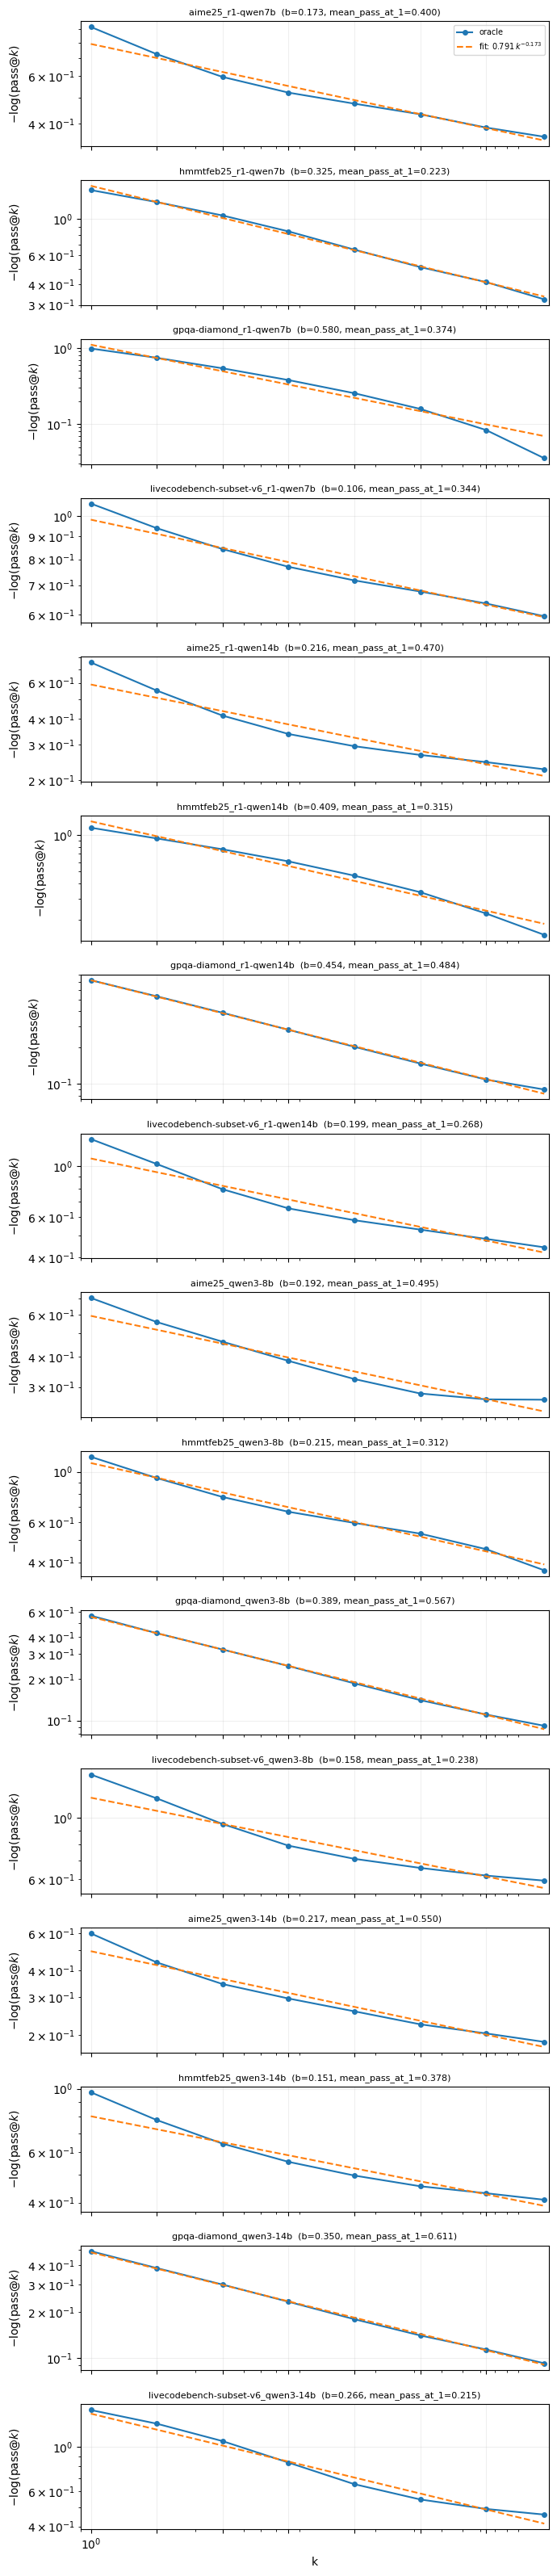

In [8]:
from scipy.optimize import curve_fit

# -log(pass@k) from full oracle data (do not overwrite `results`)
from pass_at_k import pass_at_k_rates
mean_pass_at_1_results = {}
neg_log_results = {}
for cfg in cfg_names:
    oracle_data = cfg_to_data[cfg]["data"]
    pass_at_k = pass_at_k_rates(oracle_data, k_values)  # or your (1-(1-p)**k).mean() formula
    neg_log_results[cfg] = -np.log(np.clip(pass_at_k, 1e-12, 1.0))
    mean_pass_at_1_results[cfg] = pass_at_k[0]

def power_law(k, a, b):
    """y = a * k^{-b}"""
    k = np.asarray(k, dtype=float)
    return a * np.power(k, -b)

def fit_power_law_neg_log(k, neg_log_pass_at_k):
    k = np.asarray(k, dtype=float)
    y = np.asarray(neg_log_pass_at_k, dtype=float)
    mask = (k > 0) & (y > 0) & np.isfinite(y)
    k_fit, y_fit = k[mask], y[mask]

    # log(y) = log(a) - b*log(k)
    slope, intercept = np.polyfit(np.log(k_fit), np.log(y_fit), 1)
    b0 = -slope
    a0 = np.exp(intercept)

    (a, b), _ = curve_fit(
        power_law,
        k_fit,
        y_fit,
        p0=(a0, b0),
        bounds=([1e-12, 0.0], [np.inf, np.inf]),
        maxfev=10_000,
    )
    return float(a), float(b)


# --- after neg_log_results is built ---
fig, axes = plt.subplots(n_cfg, 1, figsize=(7, 2.0 * n_cfg), sharex=True)
axes = np.atleast_1d(axes)

k_plot = np.asarray(k_values, dtype=float)
k_fine = np.geomspace(k_plot.min(), k_plot.max(), 200)  # smooth line on log-x

for row, cfg in enumerate(cfg_names):
    ax = axes[row]
    y = np.asarray(neg_log_results[cfg], dtype=float)

    a, b = fit_power_law_neg_log(k_plot, y)
    y_hat = power_law(k_fine, a, b)

    if PASSK_PLOT_POW2_K_ONLY:
        m = _mask_k_powers_of_two(k_plot)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.plot(k_plot[m], y[m], "o-", color="C0", label="oracle", linewidth=1.5, markersize=4)
    else:
        ax.plot(k_plot, y, "o-", color="C0", label="oracle", linewidth=1.5)

    ax.plot(
        k_fine,
        y_hat,
        "--",
        color="C1",
        linewidth=1.5,
        label=rf"fit: ${a:.3g}\,k^{{-{b:.3g}}}$",
    )

    ax.set_xlim(k_plot.min() * 0.9, k_plot.max() * 1.05)
    ax.set_xticks(_xticks_powers_of_two(k_plot.min(), k_plot.max()))
    ax.set_ylabel(r"$-\log(\mathrm{pass@}k)$")
    ax.grid(True, alpha=0.2)
    ax.set_title(f"{cfg}  (b={b:.3f}, mean_pass_at_1={mean_pass_at_1_results[cfg]:.3f})", fontsize=8)
    if row == 0:
        ax.legend(fontsize=7, loc="best")
    if row == n_cfg - 1:
        ax.set_xlabel("k")

plt.tight_layout()
plt.show()